# CodeAlpha Data Analytics Internship Project  
## Amazon Reviews Analytics  

**Intern Name:** Ali Ashar  
**Domain:** Data Analytics  
**Tasks Covered:**  
- Web Scraping (Conceptual Explanation)  
- Exploratory Data Analysis (EDA)  
- Data Visualization  
- Sentiment Analysis  

---

# ✅ TASK 1: Web Scraping (Conceptual Implementation)

In this task, data can be collected from Amazon product pages using Python libraries such as BeautifulSoup and Requests.

Steps involved:
1. Send HTTP request to product page.
2. Parse HTML content.
3. Extract review text, rating, price, and date.
4. Store extracted data into CSV format.
5. Use the dataset for further analysis.

For this project, an Amazon Reviews dataset is used as the collected dataset for analysis.

# ✅ TASK 2: Exploratory Data Analysis (EDA)

In this section, we explore the dataset structure, clean the data, and identify patterns and trends in customer reviews.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")

In [14]:
df = pd.read_csv("/content/7817_1.csv")

df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [16]:
df = df[['brand',
         'prices',
         'reviews.rating',
         'reviews.text',
         'reviews.date',
         'reviews.numHelpful']]

df.head()

,brand,prices,reviews.rating,reviews.text,reviews.date,reviews.numHelpful
0,Amazon,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",5.0,I initially had trouble deciding between the p...,2015-08-08T00:00:00.000Z,139.0
1,Amazon,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",5.0,Allow me to preface this with a little history...,2015-09-01T00:00:00.000Z,126.0
2,Amazon,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",4.0,I am enjoying it so far. Great for reading. Ha...,2015-07-20T00:00:00.000Z,69.0
3,Amazon,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",5.0,I bought one of the first Paperwhites and have...,2017-06-16T00:00:00.000Z,2.0
4,Amazon,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",5.0,I have to say upfront - I don't like coroporat...,2016-08-11T00:00:00.000Z,17.0


In [17]:
df = df.dropna(subset=['reviews.rating'])
df['reviews.rating'] = df['reviews.rating'].astype(int)

df.shape

(1177, 6)

In [18]:
df.isnull().sum()

,0
brand,0
prices,0
reviews.rating,0
reviews.text,0
reviews.date,217
reviews.numHelpful,277


In [19]:
df['reviews.rating'].value_counts().sort_index()

,count
reviews.rating,
1,42
2,34
3,124
4,236
5,741


### 📊 Rating Distribution Insight

The dataset shows that most customer reviews are highly positive.
5-star ratings dominate the dataset, indicating strong customer satisfaction.
Lower ratings (1 and 2 stars) are significantly fewer compared to 4 and 5 stars.

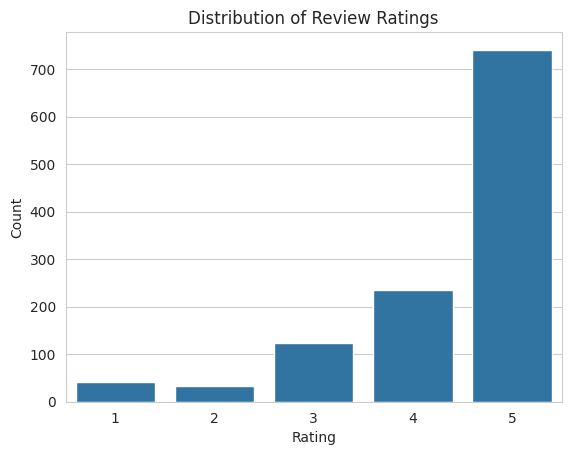

In [20]:
plt.figure()
sns.countplot(x='reviews.rating', data=df)
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [21]:
import json

def extract_price(price_str):
    try:
        price_data = json.loads(price_str)
        return float(price_data[0]['amountMax'])
    except:
        return None

df['price_clean'] = df['prices'].apply(extract_price)

df[['prices', 'price_clean']].head()

,prices,price_clean
0,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",139.99
1,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",139.99
2,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",139.99
3,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",139.99
4,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",139.99


In [22]:
df.groupby('reviews.rating')['price_clean'].mean()

,price_clean
reviews.rating,
1,65.918810
2,73.666471
3,89.829113
4,111.732034
5,93.868664


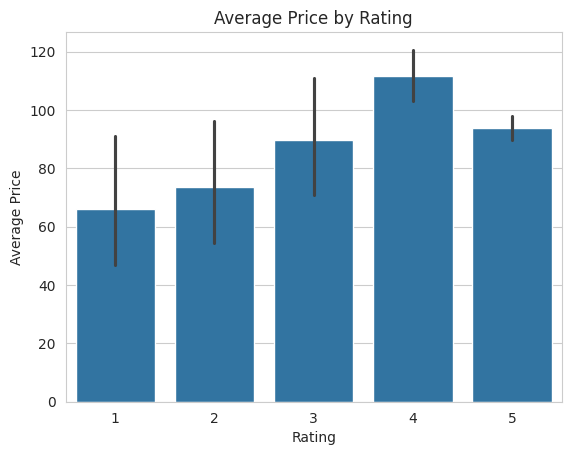

In [23]:
plt.figure()
sns.barplot(x='reviews.rating', y='price_clean', data=df)
plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()

# ✅ TASK 3: Data Visualization

In this section, we create meaningful visual representations of the dataset to uncover deeper insights and support data-driven decisions.

In [24]:
df['reviews.date'] = pd.to_datetime(df['reviews.date'], errors='coerce')

df['year'] = df['reviews.date'].dt.year

df[['reviews.date', 'year']].head()

,reviews.date,year
0,2015-08-08 00:00:00+00:00,2015.0
1,2015-09-01 00:00:00+00:00,2015.0
2,2015-07-20 00:00:00+00:00,2015.0
3,2017-06-16 00:00:00+00:00,2017.0
4,2016-08-11 00:00:00+00:00,2016.0


In [25]:
yearly_rating = df.groupby('year')['reviews.rating'].mean()

yearly_rating

,reviews.rating
year,
2012.0,4.400000
2013.0,4.666667
2014.0,4.071429
2015.0,4.176471
2016.0,4.373457
2017.0,4.419421


Rating Trend Line Plot

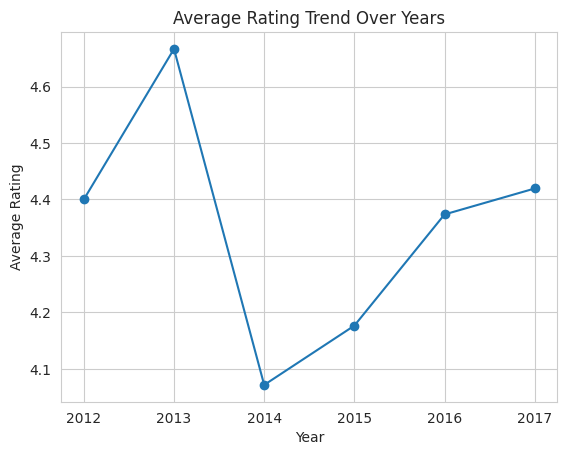

In [26]:
plt.figure()
yearly_rating.plot(marker='o')
plt.title("Average Rating Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

In [27]:
df['reviews.numHelpful'] = df['reviews.numHelpful'].fillna(0)

df.groupby('reviews.rating')['reviews.numHelpful'].mean()

,reviews.numHelpful
reviews.rating,
1,41.142857
2,82.411765
3,80.870968
4,40.300847
5,69.037787


Helpful Votes vs Rating Plot

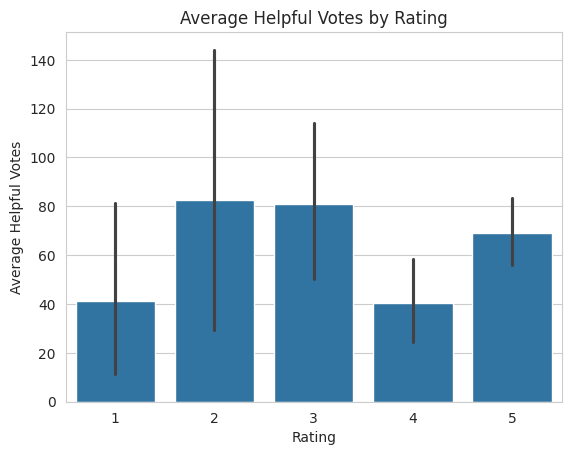

In [28]:
plt.figure()
sns.barplot(x='reviews.rating', y='reviews.numHelpful', data=df)
plt.title("Average Helpful Votes by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Helpful Votes")
plt.show()

# ✅ TASK 4: Sentiment Analysis

In this section, we apply Natural Language Processing (NLP) techniques to classify customer reviews as Positive or Negative based on review text.

In [29]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df['reviews.text'].apply(clean_text)

df[['reviews.text', 'clean_text']].head()

,reviews.text,clean_text
0,I initially had trouble deciding between the p...,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,i bought one of the first paperwhites and have...
4,I have to say upfront - I don't like coroporat...,i have to say upfront i dont like coroporate ...


In [30]:
# Remove neutral ratings (3-star)
df = df[df['reviews.rating'] != 3]

# Create sentiment column
df['sentiment'] = df['reviews.rating'].apply(lambda x: 1 if x >= 4 else 0)

df['sentiment'].value_counts()

,count
sentiment,
1,977
0,76


In [31]:
# Separate classes
positive = df[df['sentiment'] == 1]
negative = df[df['sentiment'] == 0]

# Downsample positive class
positive_downsampled = positive.sample(len(negative), random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([positive_downsampled, negative])

df_balanced['sentiment'].value_counts()

,count
sentiment,
1,76
0,76


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(df_balanced['clean_text'])
y = df_balanced['sentiment']

X.shape

(152, 2182)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((121, 2182), (31, 2182))

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

model

LogisticRegression()

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7419354838709677

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.87      0.76        15
           1       0.83      0.62      0.71        16

    accuracy                           0.74        31
   macro avg       0.76      0.75      0.74        31
weighted avg       0.76      0.74      0.74        31



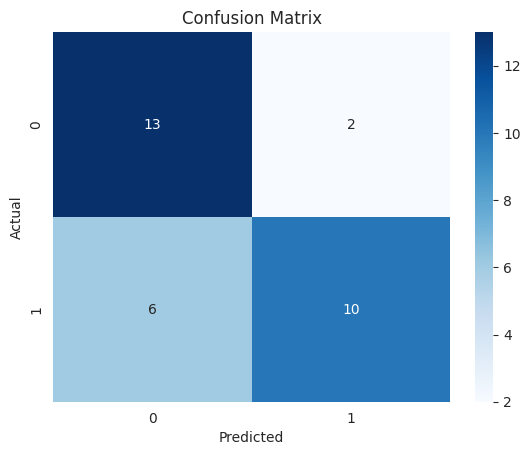

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📌 Project Conclusion

This project analyzed Amazon product reviews using data analytics and machine learning techniques.

Key Insights:

- The majority of reviews were 5-star, indicating strong customer satisfaction.
- Higher-priced products tend to receive better ratings up to 4 stars.
- Ratings showed a slight dip in 2014 but improved in later years.
- 2-star and 3-star reviews received the highest average helpful votes.
- A Logistic Regression model achieved 74% accuracy in classifying review sentiment.

This project demonstrates practical implementation of Web Scraping concepts, Exploratory Data Analysis (EDA), Data Visualization, and Sentiment Analysis using Python.